# 02 · Smishtank Dataset I — загрузка и EDA

Источник: `data/raw/Smishtank Dataset I.csv`  
Исторический черновик: [`docs/archive/dataset_design_v2.md`](../../docs/archive/dataset_design_v2.md) §4.2 использовал **`fraud_sms_phishing_like`**. **Финальная** спецификация Core: [`dataset_design_final.md`](../../docs/dataset_design_final.md) — семейство **`fraud_sms_deceptive`** (human / fraud / sms).

**Важно:** в CSV многострочные поля в кавычках → физических строк в файле больше, чем записей. Чтение: `encoding='latin-1'`, `engine='python'`.

In [1]:
# ── 0. Paths ───────────────────────────────────────────────────────────────
from pathlib import Path

def _find_v2_root() -> Path:
    candidate = Path(globals().get("__vsc_ipynb_file__", globals().get("__file__", "."))).resolve()
    for p in [candidate, *candidate.parents]:
        if (p / "pyproject.toml").exists() and (p / "notebooks").exists():
            return p
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p / "pyproject.toml").exists() and (p / "notebooks").exists():
            return p
    raise RuntimeError("Cannot find v2/ project root")

V2_ROOT = _find_v2_root()
CSV_PATH = V2_ROOT / "data" / "raw" / "Smishtank Dataset I.csv"
OUT_FIGS = V2_ROOT / "outputs" / "figures" / "data_sources"
OUT_TABLES = V2_ROOT / "outputs" / "tables"
OUT_FIGS.mkdir(parents=True, exist_ok=True)
OUT_TABLES.mkdir(parents=True, exist_ok=True)
print("CSV_PATH:", CSV_PATH)
print("exists:", CSV_PATH.exists())

CSV_PATH: /Users/askar/projects/antifraud-deepfake-detection/v2/data/raw/Smishtank Dataset I.csv
exists: True


In [2]:
# ── 1. Load CSV ────────────────────────────────────────────────────────────
import hashlib
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# UTF-8 fails on some bytes; latin-1 preserves all octets
with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=pd.errors.ParserWarning)
    df = pd.read_csv(
        CSV_PATH,
        encoding="latin-1",
        dtype=str,
        keep_default_na=False,
        engine="python",
        on_bad_lines="skip",
    )

print("Shape (rows × cols):", df.shape)
print("Columns:", list(df.columns))

Shape (rows × cols): (1062, 23)
Columns: ['messageid', 'Fulltext', 'Sender', 'SenderType', 'timeReceived', 'MainText', 'Url', 'Subdomain', 'Domain', 'TLD', 'RedirectedURL', 'Detected', 'Malicious', 'Phishing', 'Suspicious', 'Malware', 'Brand', 'URL Subcategory', 'Message Categories', 'FullyQualifiedDomain', 'Domain Registrar', 'Domain Creation Date', 'Domain Last Update']


In [3]:
# ── 2. Row integrity & text fields ─────────────────────────────────────────
df["MainText"] = df["MainText"].fillna("").astype(str)
# CSV column is "Fulltext" (one l); optional for header/body audits
if "Fulltext" in df.columns:
    df["Fulltext"] = df["Fulltext"].fillna("").astype(str)

empty_main = (df["MainText"].str.strip() == "").sum()
dup_id = df["messageid"].duplicated().sum() if "messageid" in df.columns else 0

def _md5(s: str) -> str:
    return hashlib.md5(s.strip().encode("utf-8", errors="replace")).hexdigest()

df["_text_md5"] = df["MainText"].map(_md5)
n_unique_text = df["_text_md5"].nunique()
dup_text = len(df) - n_unique_text

print(f"Empty MainText     : {empty_main}")
print(f"Duplicate messageid: {dup_id}")
print(f"Unique MainText    : {n_unique_text}  (exact-dup rows: {dup_text})")
print(f"\nMainText word count — describe:\n{df['MainText'].str.split().str.len().describe()}")

Empty MainText     : 0
Duplicate messageid: 0
Unique MainText    : 1055  (exact-dup rows: 7)

MainText word count — describe:
count    1062.000000
mean       26.878531
std        19.504062
min         1.000000
25%        14.000000
50%        20.000000
75%        35.000000
max       166.000000
Name: MainText, dtype: float64


In [4]:
# ── 3. Sender, categories, brands ───────────────────────────────────────────
col_cat = "Message Categories"
for c in ["SenderType", col_cat, "Brand", "URL Subcategory"]:
    if c not in df.columns:
        continue
    vc = df[c].replace("", "(empty)").value_counts()
    print(f"\n=== {c} (top 15) ===")
    print(vc.head(15).to_string())
    vc.to_csv(OUT_TABLES / f"smishtank_value_counts_{c.replace(' ', '_')}.csv", header=["count"])

# URL-like substring in MainText (rough)
url_pat = r"https?://|\b\w+\.\w{2,}/"
df["has_url_like"] = df["MainText"].str.contains(url_pat, case=False, regex=True)
print(f"\nMainText with URL-like pattern: {df['has_url_like'].sum()} ({100*df['has_url_like'].mean():.1f}%)")


=== SenderType (top 15) ===
SenderType
Phone Number     722
Email To Text    230
(empty)          100
Short Code        10

=== Message Categories (top 15) ===
Message Categories
Account Alert                310
Advertisement                258
Delivery                     178
Other                         92
Wrong Number/Romance Scam     65
Finance/Crypto                62
Prize/Contest                 57
Job Advertisement             24
Lawsuits/Settlements          12
Loans/Credit                   4

=== Brand (top 15) ===
Brand
(empty)            362
USPS               108
IRS                 82
Amazon              52
Netflix             44
Bank of America     31
Whatsapp            20
T-Mobile            20
Home Depot          19
Costco              15
Wells Fargo         15
CVS                 15
CITI                15
UPS                 13
Oprah               10

=== URL Subcategory (top 15) ===
URL Subcategory
Random Domain          566
(empty)                194
Deceptive s

In [5]:
# ── 4. Numeric flags (as stored in CSV — often 0/1 but not always) ─────────
flag_cols = [c for c in ["Detected", "Malicious", "Phishing", "Suspicious", "Malware"] if c in df.columns]
for c in flag_cols:
    print(f"\n{c} value_counts (top 12):")
    print(df[c].value_counts().head(12).to_string())

# Simple binary view: non-zero non-empty => flagged
def _nz(x: str) -> bool:
    x = (x or "").strip()
    if x == "" or x == "0":
        return False
    try:
        return int(x) != 0
    except ValueError:
        return True

for c in flag_cols:
    df[f"_{c}_any"] = df[c].map(_nz)
print("\nAny-nonzero interpretation:")
for c in flag_cols:
    print(f"  {c}: {df[f'_{c}_any'].sum()} ({100*df[f'_{c}_any'].mean():.1f}%)")


Detected value_counts (top 12):
Detected
0     444
1     143
      132
2      76
3      43
21     33
4      21
5      21
8      19
20     18
7      15
19     14

Malicious value_counts (top 12):
Malicious
0    533
1    189
     132
4     76
2     66
3     33
5     21
6      9
7      3

Phishing value_counts (top 12):
Phishing
0     559
      132
1     122
2      42
3      30
14     29
13     21
4      19
5      18
10     16
6      13
15     13

Suspicious value_counts (top 12):
Suspicious
0    850
     132
1     78
2      2

Malware value_counts (top 12):
Malware
0    805
     132
1     67
3     27
2     24
5      5
6      1
4      1

Any-nonzero interpretation:
  Detected: 486 (45.8%)
  Malicious: 397 (37.4%)
  Phishing: 371 (34.9%)
  Suspicious: 80 (7.5%)
  Malware: 125 (11.8%)


In [14]:
df.columns

Index(['messageid', 'Fulltext', 'Sender', 'SenderType', 'timeReceived',
       'MainText', 'Url', 'Subdomain', 'Domain', 'TLD', 'RedirectedURL',
       'Detected', 'Malicious', 'Phishing', 'Suspicious', 'Malware', 'Brand',
       'URL Subcategory', 'Message Categories', 'FullyQualifiedDomain',
       'Domain Registrar', 'Domain Creation Date', 'Domain Last Update',
       '_text_md5', 'has_url_like', '_Detected_any', '_Malicious_any',
       '_Phishing_any', '_Suspicious_any', '_Malware_any', 'year',
       'timeReceived_parsed', 'lang', 'core_like_category'],
      dtype='object')

In [6]:
# ── 5. Temporal coverage (timeReceived) ────────────────────────────────────
df["year"] = np.nan
df["timeReceived_parsed"] = pd.to_datetime(df["timeReceived"], format="%m/%d/%Y, %H:%M:%S", errors="coerce")
ok = df["timeReceived_parsed"].notna()
print(f"Parsed dates: {ok.sum()} / {len(df)}")
if ok.sum():
    print(f"  min: {df.loc[ok, 'timeReceived_parsed'].min()}")
    print(f"  max: {df.loc[ok, 'timeReceived_parsed'].max()}")
    df.loc[ok, "year"] = df.loc[ok, "timeReceived_parsed"].dt.year
    print("\nRows per year:")
    print(df["year"].value_counts(dropna=True).sort_index().to_string())

Parsed dates: 1062 / 1062
  min: 2022-03-31 21:58:50
  max: 2023-12-13 15:12:28

Rows per year:
year
2022.0    296
2023.0    766


In [7]:
# ── 6. Language (English filter; см. dataset_design_final §5.3 и archive/dataset_design_v2 §4.2) ──────────────
try:
    from langdetect import detect, LangDetectException

    def detect_lang(text: str) -> str:
        t = (text or "").strip()
        if len(t) < 20:
            return "too_short"
        try:
            return detect(t)
        except LangDetectException:
            return "unknown"

    df["lang"] = df["MainText"].map(detect_lang)
    LANG_MODE = "langdetect"
except ImportError:
    def _ascii_ratio(s: str) -> float:
        b = s.encode("utf-8", errors="ignore")
        if not b:
            return 0.0
        return sum(32 <= x < 127 or x in (9, 10, 13) for x in b) / len(b)

    df["_ascii_ratio"] = df["MainText"].map(_ascii_ratio)
    df["lang"] = np.where(
        df["MainText"].str.len() < 20,
        "too_short",
        np.where(df["_ascii_ratio"] > 0.92, "en_like_ascii", "other_ascii"),
    )
    LANG_MODE = "ascii_fallback"

print("Language mode:", LANG_MODE)
lc = df["lang"].value_counts()
print("Language (langdetect on MainText):")
print(lc.to_string())
en_n = (df["lang"] == "en").sum() if LANG_MODE == "langdetect" else (df["lang"] == "en_like_ascii").sum()
print(f"\nEnglish-like rows: {en_n} ({100*en_n/len(df):.1f}%)")
lc.to_csv(OUT_TABLES / "smishtank_lang_counts.csv", header=["count"])

Language mode: langdetect
Language (langdetect on MainText):
lang
en           1021
unknown         8
de              6
fr              6
ro              4
so              3
nl              2
pt              2
too_short       2
es              2
tr              1
no              1
cy              1
et              1
af              1
it              1

English-like rows: 1021 (96.1%)


In [8]:
# ── 7. Core-relevance heuristic (illustrative, not final labels) ───────────
# v2: fraud_sms_phishing_like — account/delivery/prize impersonation, not generic ads / wrong number
CORE_LIKE = {"Account Alert", "Delivery", "Prize/Contest", "Finance/Crypto", "Lawsuits/Settlements", "Loans/Credit"}
NON_CORE_HINT = {"Advertisement", "Wrong Number/Romance Scam", "Job Advertisement"}

df["core_like_category"] = df[col_cat].map(lambda x: "core_like" if x in CORE_LIKE else ("non_core_hint" if x in NON_CORE_HINT else "other"))
print(df["core_like_category"].value_counts().to_string())

en_mask = (df["lang"] == "en") if LANG_MODE == "langdetect" else (df["lang"] == "en_like_ascii")
core_mask = df["core_like_category"] == "core_like"
print(f"\nEnglish AND core_like category: {(en_mask & core_mask).sum()} rows")
print(f"English only: {en_mask.sum()} rows")

core_like_category
core_like        623
non_core_hint    347
other             92

English AND core_like category: 612 rows
English only: 1021 rows


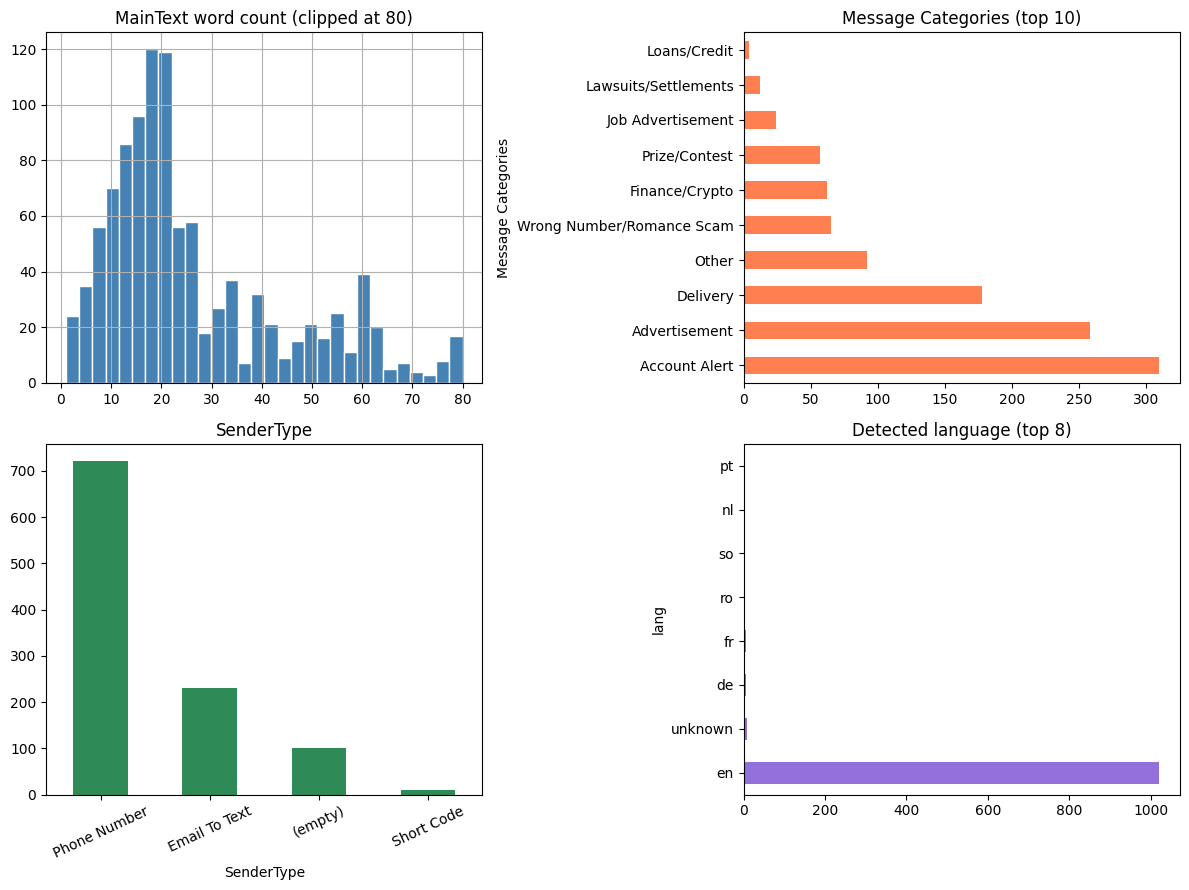

Saved /Users/askar/projects/antifraud-deepfake-detection/v2/outputs/figures/data_sources/smishtank_eda_overview.png


In [9]:
# ── 8. Figures ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

df["MainText"].str.split().str.len().clip(upper=80).hist(bins=30, ax=axes[0, 0], color="steelblue", edgecolor="white")
axes[0, 0].set_title("MainText word count (clipped at 80)")

df[col_cat].value_counts().head(10).plot(kind="barh", ax=axes[0, 1], color="coral")
axes[0, 1].set_title("Message Categories (top 10)")

df["SenderType"].replace("", "(empty)").value_counts().plot(kind="bar", ax=axes[1, 0], color="seagreen")
axes[1, 0].set_title("SenderType")
axes[1, 0].tick_params(axis="x", rotation=25)

df["lang"].value_counts().head(8).plot(kind="barh", ax=axes[1, 1], color="mediumpurple")
axes[1, 1].set_title("Detected language (top 8)")

plt.tight_layout()
fig_path = OUT_FIGS / "smishtank_eda_overview.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print("Saved", fig_path)

In [13]:
df[col_cat].value_counts()

Message Categories
Account Alert                310
Advertisement                258
Delivery                     178
Other                         92
Wrong Number/Romance Scam     65
Finance/Crypto                62
Prize/Contest                 57
Job Advertisement             24
Lawsuits/Settlements          12
Loans/Credit                   4
Name: count, dtype: int64

In [10]:
# ── 9. Export summary row for thesis / design doc ──────────────────────────
_lm = globals().get("LANG_MODE", "langdetect")
en_mask = (df["lang"] == "en") if _lm == "langdetect" else (df["lang"] == "en_like_ascii")
core_mask = df["core_like_category"] == "core_like"
summary = {
    "n_rows": len(df),
    "n_unique_maintext_md5": int(df["_text_md5"].nunique()),
    "empty_maintext": int(empty_main),
    "pct_url_like_in_main": round(100 * df["has_url_like"].mean(), 2),
    "median_words_main": float(df["MainText"].str.split().str.len().median()),
    "pct_lang_en_or_like": round(100 * en_mask.mean(), 2),
    "date_parse_ok": int(df["timeReceived_parsed"].notna().sum()),
    "year_min": float(df["year"].min()) if df["year"].notna().any() else None,
    "year_max": float(df["year"].max()) if df["year"].notna().any() else None,
    "n_core_like_category": int((df["core_like_category"] == "core_like").sum()),
    "n_en_and_core_like": int(((df["lang"] == "en") & (df["core_like_category"] == "core_like")).sum()),
}
pd.Series(summary).to_csv(OUT_TABLES / "smishtank_eda_summary.csv")
print(pd.Series(summary).to_string())

n_rows                   1062.00
n_unique_maintext_md5    1055.00
empty_maintext              0.00
pct_url_like_in_main       82.49
median_words_main          20.00
pct_lang_en_or_like        96.14
date_parse_ok            1062.00
year_min                 2022.00
year_max                 2023.00
n_core_like_category      623.00
n_en_and_core_like        612.00


## 10 · Вывод (см. `docs/archive/dataset_design_v2.md` и финал `dataset_design_final.md`)

После выполнения ячеек выше смотрите числа в выводе и `outputs/tables/smishtank_eda_summary.csv`.

**Снимок (репозиторий, прогон без langdetect — грубый ASCII-фильтр):** 1062 строки CSV → 1055 уникальных `MainText`; медиана ~20 слов; ~82% с URL-подобным фрагментом; даты 2022–2023; иллюстративно **~623** строк в категориях «как Core phishing-like» и **~619** пересечение с English-like (уточняйте через `langdetect` в ноутбуке).

**Соответствие Core (§4.2):**
- Роль датасета в v2: **единственный** заявленный human anchor для `fraud / sms / fraud_sms_phishing_like` вместо широкого SMS Spam Collection.
- Содержательно тексты в основном **имитация брендов / доставки / счетов / призов** — это хорошо бьётся в сценарий phishing-like SMS.
- Ограничения, которые нужно закрыть пайплайном: **(1)** только английский — фильтр по `lang==en`; **(2)** дедуп по `MainText`; **(3)** часть категорий (`Advertisement`, `Wrong Number/Romance Scam`, …) **не** должна попадать в Core без отдельного решения; **(4)** объём ~1k строк после дедупа — планировать **matching** по объёму с LLM-веткой; **(5)** колонки `Malicious`/`Phishing`/… не строго бинарные — для разметки опирайтесь на `Message Categories` + текст, а не слепо на флаги.

**Итог:** источник **подходит** как кандидат на Core при явных правилах отбора (English, дедуп, сужение по категориям к phishing-like), в духе «не раздувать сценарий до всего SMS spam» (§4.2).